In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import defaultdict

## Evaluation Metrics

In [2]:
def yolo_to_xyxy(bbox):
    """Convert YOLO format [cx, cy, w, h] to [x1, y1, x2, y2]."""
    cx, cy, w, h = bbox
    return [cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2]

In [3]:
def compute_iou(box1, box2):
    """Compute IoU between two boxes in xyxy format."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    if union == 0:
        return 0.0
    return intersection / union

In [4]:
def match_predictions(gt_by_image, preds_by_image, class_id, iou_threshold=0.5):
    """Match predictions to ground-truth for a single class.

    1. Collect all predictions for this class across all images
    2. Sort by confidence (descending)
    3. For each prediction, find the best-matching unmatched GT box (highest IoU)
    4. If best IoU >= threshold and GT not yet matched -> TP, else FP

    Returns: tp_list, fp_list, num_gt (total ground-truth boxes for this class)
    """
    all_preds = []
    num_gt = 0
    gt_matched = {}

    for image_id, gt_boxes in gt_by_image.items():
        class_gt = [b for b in gt_boxes if b["class_id"] == class_id]
        num_gt += len(class_gt)
        gt_matched[image_id] = [False] * len(class_gt)

    for image_id, pred_boxes in preds_by_image.items():
        for pred in pred_boxes:
            if pred["class_id"] == class_id:
                all_preds.append((image_id, pred))

    all_preds.sort(key=lambda x: x[1].get("confidence", 0), reverse=True)

    tp = np.zeros(len(all_preds))
    fp = np.zeros(len(all_preds))

    for i, (image_id, pred) in enumerate(all_preds):
        pred_box = yolo_to_xyxy(pred["bbox"])

        class_gt = [b for b in gt_by_image.get(image_id, []) if b["class_id"] == class_id]

        best_iou = 0
        best_gt_idx = -1
        for j, gt in enumerate(class_gt):
            gt_box = yolo_to_xyxy(gt["bbox"])
            iou = compute_iou(pred_box, gt_box)
            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j

        if best_iou >= iou_threshold and not gt_matched[image_id][best_gt_idx]:
            tp[i] = 1
            gt_matched[image_id][best_gt_idx] = True
        else:
            fp[i] = 1

    return tp, fp, num_gt

In [5]:
def compute_precision_recall(tp, fp, num_gt):
    """Compute cumulative precision and recall arrays from TP/FP arrays."""
    tp_cumsum = np.cumsum(tp)
    fp_cumsum = np.cumsum(fp)

    precision = tp_cumsum / (tp_cumsum + fp_cumsum)
    recall = tp_cumsum / num_gt if num_gt > 0 else tp_cumsum

    return precision, recall

def compute_f1(precision, recall):
    """Compute F1 score from precision and recall (scalar or array)."""
    denom = precision + recall
    return np.where(denom == 0, 0.0, 2 * precision * recall / denom)

In [6]:
def compute_ap(tp, fp, num_gt):
    """Compute Average Precision for one class.

    1. Build cumulative precision/recall arrays
    2. Apply precision envelope correction (monotonically decreasing)
    3. Compute AP as the area under the corrected PR curve
    """
    if num_gt == 0:
        return 0.0, np.array([]), np.array([])

    precision, recall = compute_precision_recall(tp, fp, num_gt)

    # Prepend (recall=0, precision=1) for area computation
    recall = np.concatenate(([0.0], recall))
    precision = np.concatenate(([1.0], precision))

    # Precision envelope: traverse from end to start,
    # replace each precision by the max precision at any higher recall
    for i in range(len(precision) - 2, -1, -1):
        precision[i] = max(precision[i], precision[i + 1])

    # Compute AP as sum of rectangular areas
    ap = 0.0
    for i in range(1, len(recall)):
        ap += (recall[i] - recall[i - 1]) * precision[i]

    return ap, precision, recall

In [7]:
def compute_map(gt_by_image, preds_by_image, all_classes, iou_threshold=0.5):
    """Compute mAP across all classes at a given IoU threshold.
    Returns: mAP (float), per-class results (dict)."""
    per_class = {}

    for cls in all_classes:
        tp, fp, num_gt = match_predictions(gt_by_image, preds_by_image, cls, iou_threshold)
        ap, precision, recall = compute_ap(tp, fp, num_gt)

        total_tp = int(tp.sum())
        total_fp = int(fp.sum())
        final_prec = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
        final_rec = total_tp / num_gt if num_gt > 0 else 0.0
        f1 = 2 * final_prec * final_rec / (final_prec + final_rec) if (final_prec + final_rec) > 0 else 0.0

        per_class[cls] = {
            "ap": ap,
            "precision": final_prec,
            "recall": final_rec,
            "f1": f1,
            "num_gt": num_gt,
            "num_preds": len(tp),
            "tp": total_tp,
            "fp": total_fp,
            "pr_curve_precision": precision,
            "pr_curve_recall": recall,
        }

    map_val = np.mean([v["ap"] for v in per_class.values()]) if per_class else 0.0
    return map_val, per_class

## Setup & Configuration

In [10]:
!pip install ultralytics rfdetr wandb -q
# !pip install "rfdetr[train,loggers]"

import json
import shutil
import random
import cv2
import wandb
from pathlib import Path
from google.colab import drive
from ultralytics import YOLO

drive.mount("/content/drive")
wandb.login()

BASE_DIR = Path("mixed_flowers")
SAVE_DIR = Path("/content/drive/MyDrive/CompVision/lab6_runs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
PROJECT = str(SAVE_DIR)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 83.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: andreea-ghe (andreea-ghe-babes-bolyai-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [11]:
!unzip "/content/drive/MyDrive/CompVision/mixed_flowers.zip" -d "/content"

Streaming output truncated to the last 5000 lines.
  inflating: /content/mixed_flowers/masks/mask_004439.png  
  inflating: /content/mixed_flowers/masks/mask_004440.png  
  inflating: /content/mixed_flowers/masks/mask_004441.png  
  inflating: /content/mixed_flowers/masks/mask_004442.png  
  inflating: /content/mixed_flowers/masks/mask_004443.png  
  inflating: /content/mixed_flowers/masks/mask_004444.png  
  inflating: /content/mixed_flowers/masks/mask_004445.png  
  inflating: /content/mixed_flowers/masks/mask_004446.png  
  inflating: /content/mixed_flowers/masks/mask_004447.png  
  inflating: /content/mixed_flowers/masks/mask_004448.png  
  inflating: /content/mixed_flowers/masks/mask_004449.png  
  inflating: /content/mixed_flowers/masks/mask_004450.png  
  inflating: /content/mixed_flowers/masks/mask_004451.png  
  inflating: /content/mixed_flowers/masks/mask_004452.png  
  inflating: /content/mixed_flowers/masks/mask_004453.png  
  inflating: /content/mixed_flowers/masks/mask_00

## Dataset Preparation

Split the merged COCO dataset into train / val / test (70/15/15).  
Create **two** formats so both models can train directly:

| Model | Format | Structure |
|-------|--------|-----------|
| YOLO26 | YOLO txt | `dataset_yolo/{split}/images/` + `labels/` + `data.yaml` |
| RF-DETR | COCO JSON | `dataset_coco/{split}/_annotations.coco.json` + images |

Then duplicate the train split with synthetic images added for the **real+synthetic** experiments.

In [17]:
with open(BASE_DIR / "_annotations.coco.json") as f:
    coco = json.load(f)

cat_map = {c["id"]: c["name"] for c in coco["categories"]}
num_classes = len(cat_map)
print(f"Classes ({num_classes}): {list(cat_map.values())}")

img_map = {img["id"]: img for img in coco["images"]}
ann_by_img = defaultdict(list)
for ann in coco["annotations"]:
    ann_by_img[ann["image_id"]].append(ann)

all_img_ids = list(img_map.keys())
random.shuffle(all_img_ids)
n = len(all_img_ids)
n_train, n_val = int(0.70 * n), int(0.15 * n)

split_ids = {
    "train": set(all_img_ids[:n_train]),
    "valid": set(all_img_ids[n_train:n_train + n_val]),
    "test":  set(all_img_ids[n_train + n_val:]),
}
for s, ids in split_ids.items():
    print(f"  {s}: {len(ids)} images")

# ── YOLO-format dataset ──
YOLO_DIR = Path("dataset_yolo")
for split, ids in split_ids.items():
    img_dir = YOLO_DIR / split / "images"
    lbl_dir = YOLO_DIR / split / "labels"
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    for img_id in ids:
        info = img_map[img_id]
        fn = info["file_name"]
        src = BASE_DIR / "images" / fn
        if not src.exists():
            continue
        shutil.copy2(src, img_dir / fn)

        iw, ih = float(info["width"]), float(info["height"])
        lines = []
        for ann in ann_by_img.get(img_id, []):
            x, y, w, h = [float(v) for v in ann["bbox"]]
            lines.append(
                f"{ann['category_id']} {(x+w/2)/iw:.6f} {(y+h/2)/ih:.6f} {w/iw:.6f} {h/ih:.6f}"
            )
        (lbl_dir / f"{Path(fn).stem}.txt").write_text("\n".join(lines))

names_dict = {i: cat_map[i] for i in sorted(cat_map)}
(YOLO_DIR / "data.yaml").write_text(
    f"path: {YOLO_DIR.resolve()}\n"
    f"train: train/images\nval: valid/images\ntest: test/images\n"
    f"nc: {num_classes}\nnames: {names_dict}\n"
)

# ── COCO-format dataset ──
COCO_DIR = Path("dataset_coco")
for split, ids in split_ids.items():
    split_dir = COCO_DIR / split
    split_dir.mkdir(parents=True, exist_ok=True)

    split_images = [img_map[i] for i in ids if i in img_map]
    split_anns = [a for a in coco["annotations"] if a["image_id"] in ids]

    # Sanitize: ensure all bbox/area values are numeric (some sources store as strings)
    for ann in split_anns:
        ann["bbox"] = [float(v) for v in ann["bbox"]]
        if "area" in ann:
            ann["area"] = float(ann["area"])
    for img in split_images:
        img["width"] = int(img["width"])
        img["height"] = int(img["height"])

    with open(split_dir / "_annotations.coco.json", "w") as f:
        json.dump({"images": split_images, "annotations": split_anns,
                    "categories": coco["categories"]}, f)

    for info in split_images:
        src = BASE_DIR / "images" / info["file_name"]
        if src.exists():
            shutil.copy2(src, split_dir / info["file_name"])

print(f"\nYOLO dataset: {YOLO_DIR}")
print(f"COCO dataset: {COCO_DIR} (bbox values sanitized)")

Classes (16): ['butterfly flower', 'cape flower', 'cyclamen', 'dahlia', 'daisy', 'dandelion', 'foxglove', 'frangipani', 'jasmine', 'orchid', 'passion flower', 'petunia', 'rose', 'sunflower', 'wallflower', 'ylang-ylang']
  train: 3713 images
  valid: 795 images
  test: 797 images

YOLO dataset: dataset_yolo
COCO dataset: dataset_coco (bbox values sanitized)


In [18]:
# ── Create real+synthetic variants ──
YOLO_SYNTH_DIR = Path("dataset_yolo_synth")
COCO_SYNTH_DIR = Path("dataset_coco_synth")
shutil.copytree(YOLO_DIR, YOLO_SYNTH_DIR, dirs_exist_ok=True)
shutil.copytree(COCO_DIR, COCO_SYNTH_DIR, dirs_exist_ok=True)

with open(BASE_DIR / "synthetic" / "_annotations.coco.json") as f:
    synth_coco = json.load(f)

synth_ann_by_img = defaultdict(list)
for ann in synth_coco["annotations"]:
    synth_ann_by_img[ann["image_id"]].append(ann)

synth_count = 0
for img_info in synth_coco["images"]:
    fn = img_info["file_name"]
    src = BASE_DIR / "synthetic" / "images" / fn
    if not src.exists():
        continue
    synth_fn = f"synth_{fn}"

    # YOLO
    shutil.copy2(src, YOLO_SYNTH_DIR / "train" / "images" / synth_fn)
    iw, ih = float(img_info["width"]), float(img_info["height"])
    lines = []
    for ann in synth_ann_by_img.get(img_info["id"], []):
        x, y, w, h = [float(v) for v in ann["bbox"]]
        lines.append(
            f"{ann['category_id']} {(x+w/2)/iw:.6f} {(y+h/2)/ih:.6f} {w/iw:.6f} {h/ih:.6f}"
        )
    (YOLO_SYNTH_DIR / "train" / "labels" / f"{Path(synth_fn).stem}.txt").write_text("\n".join(lines))
    synth_count += 1

# Update YOLO data.yaml
(YOLO_SYNTH_DIR / "data.yaml").write_text(
    f"path: {YOLO_SYNTH_DIR.resolve()}\n"
    f"train: train/images\nval: valid/images\ntest: test/images\n"
    f"nc: {num_classes}\nnames: {names_dict}\n"
)

# COCO: append synthetic images + annotations to train split
with open(COCO_SYNTH_DIR / "train" / "_annotations.coco.json") as f:
    train_coco = json.load(f)

max_img_id = max(img["id"] for img in train_coco["images"]) + 1
max_ann_id = max(a["id"] for a in train_coco["annotations"]) + 1

for img_info in synth_coco["images"]:
    fn = img_info["file_name"]
    synth_fn = f"synth_{fn}"
    src = BASE_DIR / "synthetic" / "images" / fn
    if not src.exists():
        continue
    shutil.copy2(src, COCO_SYNTH_DIR / "train" / synth_fn)

    new_img = dict(img_info, id=max_img_id, file_name=synth_fn)
    train_coco["images"].append(new_img)

    for ann in synth_ann_by_img.get(img_info["id"], []):
        train_coco["annotations"].append(dict(ann, id=max_ann_id, image_id=max_img_id))
        max_ann_id += 1
    max_img_id += 1

# Sanitize all bbox/area/dimensions in the merged COCO JSON
for ann in train_coco["annotations"]:
    ann["bbox"] = [float(v) for v in ann["bbox"]]
    if "area" in ann:
        ann["area"] = float(ann["area"])
for img in train_coco["images"]:
    img["width"] = int(img["width"])
    img["height"] = int(img["height"])

with open(COCO_SYNTH_DIR / "train" / "_annotations.coco.json", "w") as f:
    json.dump(train_coco, f)

# Also sanitize valid/test splits in the synth copy
for split in ["valid", "test"]:
    p = COCO_SYNTH_DIR / split / "_annotations.coco.json"
    with open(p) as f:
        d = json.load(f)
    for ann in d["annotations"]:
        ann["bbox"] = [float(v) for v in ann["bbox"]]
        if "area" in ann:
            ann["area"] = float(ann["area"])
    for img in d["images"]:
        img["width"] = int(img["width"])
        img["height"] = int(img["height"])
    with open(p, "w") as f:
        json.dump(d, f)

print(f"Added {synth_count} synthetic images to train sets")
real_n = len(list((YOLO_DIR / "train/images").iterdir()))
synth_n = len(list((YOLO_SYNTH_DIR / "train/images").iterdir()))
print(f"Real-only train: {real_n} images  |  Real+synth train: {synth_n} images")

Added 482 synthetic images to train sets
Real-only train: 4822 images  |  Real+synth train: 5304 images


## Train YOLO26

Fine-tune **YOLO26s** from COCO-pretrained weights.  
Two runs: real-only data and real+synthetic data.  
Ultralytics automatically logs to **wandb** when the package is installed.

In [14]:
os.environ["WANDB_PROJECT"] = "lab6-flower-detection"

yolo_real = YOLO("yolo26s.pt")
yolo_real.train(
    data=str(YOLO_DIR / "data.yaml"),
    epochs=10,
    imgsz=640,
    batch=16,
    project=PROJECT,
    name="yolo26s_real",
    seed=SEED,
    patience=10,
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26s_real, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/05/20 20:10:52 INFO mlflow.tracking.fluent: Experiment with name '/content/drive/MyDrive/CompVision/lab6_runs' does not exist. Creating a new experiment.
2026/05/20 20:10:53 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/05/20 20:10:53 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/05/20 20:10:53 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


MLflow: logging run_id(a7986b1adcf14f7e922fb233d1d47b2e) to runs/mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs/mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /content/drive/MyDrive/CompVision/lab6_runs/yolo26s_real
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/10      4.64G       1.23      11.18    0.02634          1        640: 100% ━━━━━━━━━━━━ 233/233 3.9it/s 59.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 1.3s/it 32.4s
                   all        795       1375      0.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x781291b642f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044

In [15]:
yolo_synth = YOLO("yolo26s.pt")
yolo_synth.train(
    data=str(YOLO_SYNTH_DIR / "data.yaml"),
    epochs=10,
    imgsz=640,
    batch=16,
    project=PROJECT,
    name="yolo26s_real_synth",
    seed=SEED,
    patience=10,
)

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset_yolo_synth/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26s_real_synth, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap

2026/05/20 20:18:56 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/05/20 20:18:56 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/05/20 20:18:56 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


MLflow: logging run_id(812f1c17496144d28db1ad79110ed962) to runs/mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs/mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to /content/drive/MyDrive/CompVision/lab6_runs/yolo26s_real_synth
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       1/10      4.81G      1.158      10.41     0.0235          3        640: 100% ━━━━━━━━━━━━ 263/263 4.8it/s 55.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 8.0it/s 3.1s
                   all        795       1375   

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7812903b1670>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044

## Train RF-DETR

Fine-tune **RF-DETR Base** (DINOv2 backbone, ~30M params).  
Two runs: real-only and real+synthetic.  
Use `batch_size=4` + `grad_accum_steps=4` for an effective batch of 16 (fits T4 16 GB).

In [19]:
from rfdetr import RFDETRBase

rfdetr_real = RFDETRBase()
rfdetr_real.train(
    dataset_dir=str(COCO_DIR),
    epochs=10,
    batch_size=4,
    grad_accum_steps=4,
    lr=1e-4,
    output_dir=f"{PROJECT}/rfdetr_real",
)

[2026-05-20 20:37:15] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-20 20:37:17] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-05-20 20:37:19] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-05-20 20:37:20] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 16. The detection head will be re-initialized to 16 classes.
INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026/05/20 20:37:20 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'aa0cdfb053b049489295c64f296b177b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current pytorch workflow


[2026-05-20 20:37:20] [INFO] rf-detr - Building Roboflow train dataset with square resize at resolution 560
[2026-05-20 20:37:20] [INFO] rf-detr - Using multi-scale training with square resize and scales: [840]
[2026-05-20 20:37:20] [INFO] rf-detr - Built 1 Albumentations transforms from config
[2026-05-20 20:37:20] [INFO] rf-detr - Built 1 Albumentations transforms from config
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
[2026-05-20 20:37:20] [INFO] rf-detr - Building Roboflow val dataset with square resize at resolution 560
[2026-05-20 20:37:20] [INFO] rf-detr - Using multi-scale training with square resize and scales: [840]
[2026-05-20 20:37:20] [INFO] rf-detr - Built 1 Albumentations transforms from config


/usr/local/lib/python3.12/dist-packages/lightning_fabric/loggers/csv_logs.py:268: Experiment logs directory /content/drive/MyDrive/CompVision/lab6_runs/rfdetr_real/ exists and is not empty. Previous log files in this directory will be deleted when the new ones are saved!
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


...

2026/05/20 21:18:31 WARNING mlflow.utils.checkpoint_utils: Checkpoint logging is skipped, because checkpoint 'save_best_only' config is True, it requires to compare the monitored metric value, but the provided monitored metric value is not available.


[2026-05-20 21:23:08] [INFO] rf-detr - Best regular mAP saved to /content/drive/MyDrive/CompVision/lab6_runs/rfdetr_real/checkpoint_best_regular.pth (epoch 9)
[2026-05-20 21:23:08] [INFO] rf-detr - Best EMA mAP improved to 0.5773 (epoch 9)


2026/05/20 21:23:08 WARNING mlflow.utils.checkpoint_utils: Checkpoint logging is skipped, because checkpoint 'save_best_only' config is True, it requires to compare the monitored metric value, but the provided monitored metric value is not available.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


[2026-05-20 21:23:21] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.5621, ema=0.5773)


2026/05/20 21:23:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/20 21:23:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


In [ ]:
# rfdetr_synth = RFDETRBase()
# rfdetr_synth.train(
#     dataset_dir=str(COCO_SYNTH_DIR),
#     epochs=10,
#     batch_size=4,
#     grad_accum_steps=4,
#     lr=1e-4,
#     output_dir=f"{PROJECT}/rfdetr_real_synth",
# )

## Inference & Evaluation

Run each trained model on the **test set**, parse predictions into the format
expected by our from-scratch metrics (`gt_by_image`, `preds_by_image`), then
compute IoU, Precision, Recall, AP, and mAP for each case study.

In [20]:
TEST_IMG_DIR = YOLO_DIR / "test" / "images"
TEST_LBL_DIR = YOLO_DIR / "test" / "labels"
ALL_CLASSES = sorted(cat_map.keys())

def load_gt(test_img_dir=TEST_IMG_DIR, test_lbl_dir=TEST_LBL_DIR):
    """Load ground-truth labels from YOLO-format .txt files."""
    gt = {}
    for img_path in sorted(test_img_dir.glob("*.*")):
        img_id = img_path.stem
        lbl = test_lbl_dir / f"{img_id}.txt"
        boxes = []
        if lbl.exists():
            for line in lbl.read_text().strip().split("\n"):
                if not line.strip():
                    continue
                parts = line.split()
                boxes.append({
                    "class_id": int(parts[0]),
                    "bbox": list(map(float, parts[1:5])),
                })
        gt[img_id] = boxes
    return gt

def predict_yolo(model_path, test_img_dir=TEST_IMG_DIR):
    """Run YOLO model on test images, return preds_by_image."""
    model = YOLO(model_path)
    preds = {}
    for img_path in sorted(test_img_dir.glob("*.*")):
        img_id = img_path.stem
        results = model.predict(str(img_path), verbose=False, conf=0.25)[0]
        boxes = []
        if results.boxes is not None and len(results.boxes):
            iw, ih = results.orig_shape[1], results.orig_shape[0]
            for box in results.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                boxes.append({
                    "class_id": int(box.cls[0]),
                    "confidence": float(box.conf[0]),
                    "bbox": [
                        ((x1 + x2) / 2) / iw,
                        ((y1 + y2) / 2) / ih,
                        (x2 - x1) / iw,
                        (y2 - y1) / ih,
                    ],
                })
        preds[img_id] = boxes
    return preds

def predict_rfdetr(checkpoint_path, test_img_dir=TEST_IMG_DIR):
    """Run RF-DETR model on test images, return preds_by_image."""
    model = RFDETRBase(pretrain_weights=checkpoint_path)
    preds = {}
    for img_path in sorted(test_img_dir.glob("*.*")):
        img_id = img_path.stem
        image = cv2.imread(str(img_path))
        detections = model.predict(image, threshold=0.25)
        boxes = []
        if len(detections) > 0:
            ih, iw = image.shape[:2]
            for i in range(len(detections)):
                x1, y1, x2, y2 = detections.xyxy[i]
                boxes.append({
                    "class_id": int(detections.class_id[i]),
                    "confidence": float(detections.confidence[i]),
                    "bbox": [
                        ((x1 + x2) / 2) / iw,
                        ((y1 + y2) / 2) / ih,
                        (x2 - x1) / iw,
                        (y2 - y1) / ih,
                    ],
                })
        preds[img_id] = boxes
    return preds

In [21]:
# ── Collect predictions from 3 models ──
gt = load_gt()
print(f"Test set: {len(gt)} images, {sum(len(v) for v in gt.values())} GT boxes\n")

# Adjust these paths if training produced different directory names
YOLO_REAL_BEST     = str(SAVE_DIR / "yolo26s_real" / "weights" / "best.pt")
YOLO_SYNTH_BEST    = str(SAVE_DIR / "yolo26s_real_synth" / "weights" / "best.pt")
RFDETR_REAL_BEST   = str(SAVE_DIR / "rfdetr_real" / "checkpoint_best_total.pth")

for p in [YOLO_REAL_BEST, YOLO_SYNTH_BEST, RFDETR_REAL_BEST]:
    print(f"  {'OK' if Path(p).exists() else 'MISSING'}: {p}")

print("Running YOLO26 (real-only) …")
preds_yolo_real = predict_yolo(YOLO_REAL_BEST)

print("Running YOLO26 (real+synth) …")
preds_yolo_synth = predict_yolo(YOLO_SYNTH_BEST)

print("Running RF-DETR (real-only) …")
preds_rfdetr_real = predict_rfdetr(RFDETR_REAL_BEST)

print("\nAll predictions collected.")

Test set: 1470 images, 2514 GT boxes

  OK: /content/drive/MyDrive/CompVision/lab6_runs/yolo26s_real/weights/best.pt
  OK: /content/drive/MyDrive/CompVision/lab6_runs/yolo26s_real_synth/weights/best.pt
  OK: /content/drive/MyDrive/CompVision/lab6_runs/rfdetr_real/checkpoint_best_total.pth
Running YOLO26 (real-only) …
Running YOLO26 (real+synth) …
Running RF-DETR (real-only) …


[2026-05-20 21:32:16] [WARNING] rf-detr - Checkpoint has 16 classes but model is configured for 90. Using checkpoint class count (16). Pass num_classes=16 to suppress this warning.
[2026-05-20 21:32:17] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().



All predictions collected.


In [22]:
# ── Analysis & visualization helpers ──

def analyze_model(gt_by_image, preds_by_image, model_name):
    """Full case-study analysis: metrics table + PR curves + per-class AP bar chart."""
    map50, pc50 = compute_map(gt_by_image, preds_by_image, ALL_CLASSES, iou_threshold=0.5)
    map75, pc75 = compute_map(gt_by_image, preds_by_image, ALL_CLASSES, iou_threshold=0.75)

    print(f"{'=' * 70}")
    print(f"  {model_name}")
    print(f"{'=' * 70}")
    print(f"  mAP@0.5 = {map50:.4f}    mAP@0.75 = {map75:.4f}\n")
    print(f"  {'Class':<20} {'AP@0.5':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'GT':>6} {'TP':>6} {'FP':>6}")
    print(f"  {'-'*76}")
    for c in ALL_CLASSES:
        r = pc50[c]
        print(f"  {cat_map[c]:<20} {r['ap']:>8.3f} {r['precision']:>8.3f} "
              f"{r['recall']:>8.3f} {r['f1']:>8.3f} {r['num_gt']:>6d} {r['tp']:>6d} {r['fp']:>6d}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # PR curves
    ax = axes[0]
    for c in ALL_CLASSES:
        r = pc50[c]
        if len(r["pr_curve_recall"]) > 0:
            ax.plot(r["pr_curve_recall"], r["pr_curve_precision"],
                    label=f"{cat_map[c]} ({r['ap']:.2f})")
    ax.set(xlabel="Recall", ylabel="Precision", title=f"{model_name} — PR Curves (IoU=0.5)",
           xlim=(0, 1), ylim=(0, 1.05))
    ax.legend(fontsize=6, loc="lower left")
    ax.grid(True, alpha=0.3)

    # Per-class AP
    ax = axes[1]
    names_sorted = [cat_map[c] for c in ALL_CLASSES]
    aps = [pc50[c]["ap"] for c in ALL_CLASSES]
    colors = plt.cm.tab20(np.linspace(0, 1, num_classes))
    ax.barh(names_sorted, aps, color=colors)
    ax.axvline(map50, color="red", ls="--", lw=1.5, label=f"mAP = {map50:.3f}")
    ax.set(xlabel="AP@0.5", title=f"{model_name} — Per-class AP", xlim=(0, 1))
    ax.legend()

    plt.tight_layout()
    plt.show()
    return map50, map75, pc50


def visualize_predictions(gt_by_image, preds_by_image, model_name, test_img_dir=TEST_IMG_DIR, n=6, conf_thr=0.3):
    """Side-by-side GT vs prediction boxes on sample images."""
    ids = [k for k in gt_by_image if len(gt_by_image[k]) > 0][:n]
    cmap = plt.cm.tab20(np.linspace(0, 1, 20))

    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for i, img_id in enumerate(ids):
        img_files = list(test_img_dir.glob(f"{img_id}.*"))
        if not img_files:
            continue
        img = Image.open(img_files[0])
        w, h = img.size

        for col, (title, boxes) in enumerate([
            ("Ground Truth", gt_by_image[img_id]),
            (f"Predictions ({model_name})", preds_by_image.get(img_id, [])),
        ]):
            axes[i, col].imshow(img)
            axes[i, col].set_title(title, fontsize=10)
            axes[i, col].axis("off")
            for b in boxes:
                if "confidence" in b and b["confidence"] < conf_thr:
                    continue
                cx, cy, bw, bh = b["bbox"]
                x1, y1 = (cx - bw / 2) * w, (cy - bh / 2) * h
                c = cmap[b["class_id"] % 20]
                rect = patches.Rectangle((x1, y1), bw * w, bh * h,
                                         lw=2, edgecolor=c, facecolor="none")
                axes[i, col].add_patch(rect)
                label = cat_map.get(b["class_id"], "?")
                if "confidence" in b:
                    label += f" {b['confidence']:.2f}"
                axes[i, col].text(x1, max(y1 - 4, 0), label, fontsize=6,
                                  color="white",
                                  bbox=dict(boxstyle="round,pad=0.15",
                                            facecolor=c, alpha=0.85))
    plt.tight_layout()
    plt.show()

## Case Study 1 — YOLO26 (real-only)

Analyze the behaviour of the CNN-based one-stage detector.  
Focus on: per-class AP spread, precision vs recall trade-off, which flower
classes are easy/hard, and what the failure modes look like (missed detections,
duplicates, mis-localization, class confusion).

  YOLO26s — real-only
  mAP@0.5 = 0.6217    mAP@0.75 = 0.5082

  Class                  AP@0.5     Prec      Rec       F1     GT     TP     FP
  ----------------------------------------------------------------------------
  butterfly flower        0.335    0.605    0.451    0.517    173     78     51
  cape flower             0.673    0.720    0.748    0.733    103     77     30
  cyclamen                0.658    0.791    0.671    0.726     79     53     14
  dahlia                  0.780    0.848    0.796    0.821     98     78     14
  daisy                   0.835    0.880    0.843    0.861    261    220     30
  dandelion               0.844    0.869    0.859    0.864    248    213     32
  foxglove                0.617    0.716    0.675    0.695    123     83     33
  frangipani              0.525    0.788    0.545    0.644    123     67     18
  jasmine                 0.326    0.648    0.410    0.502    261    107     58
  orchid                  0.683    0.740    0.733    0.736

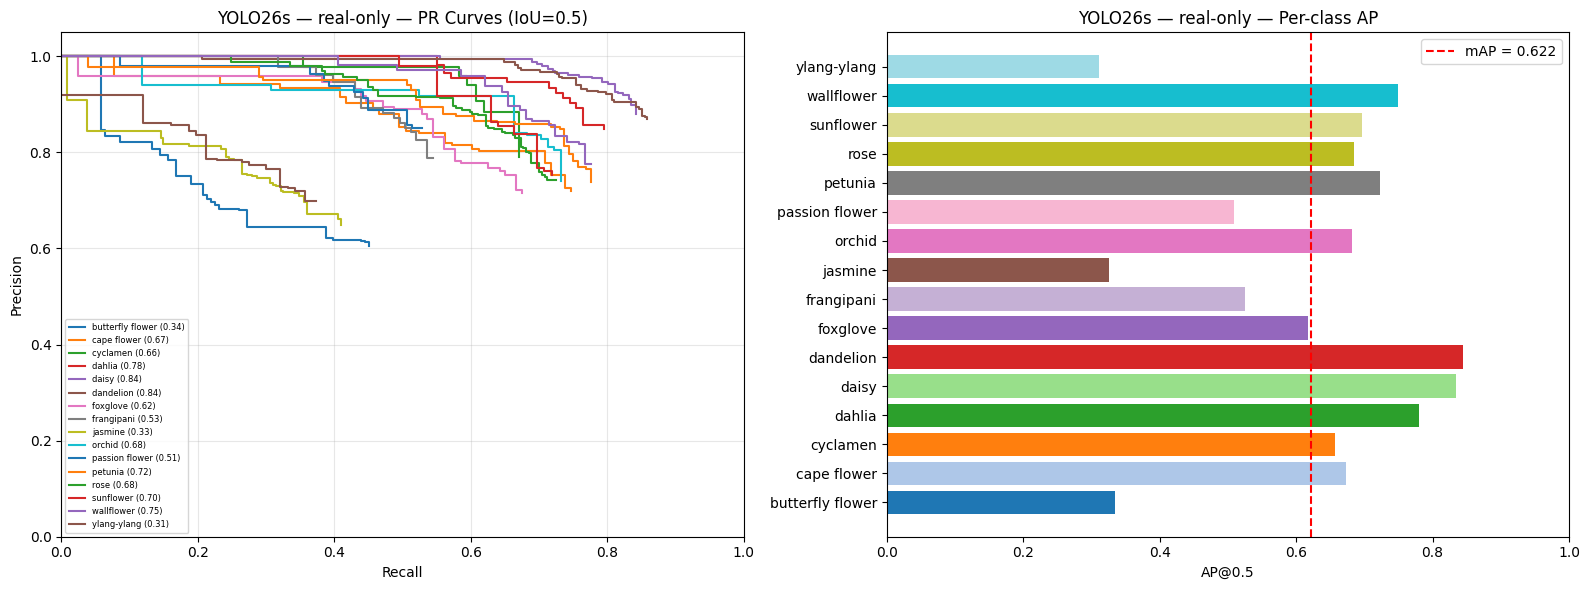

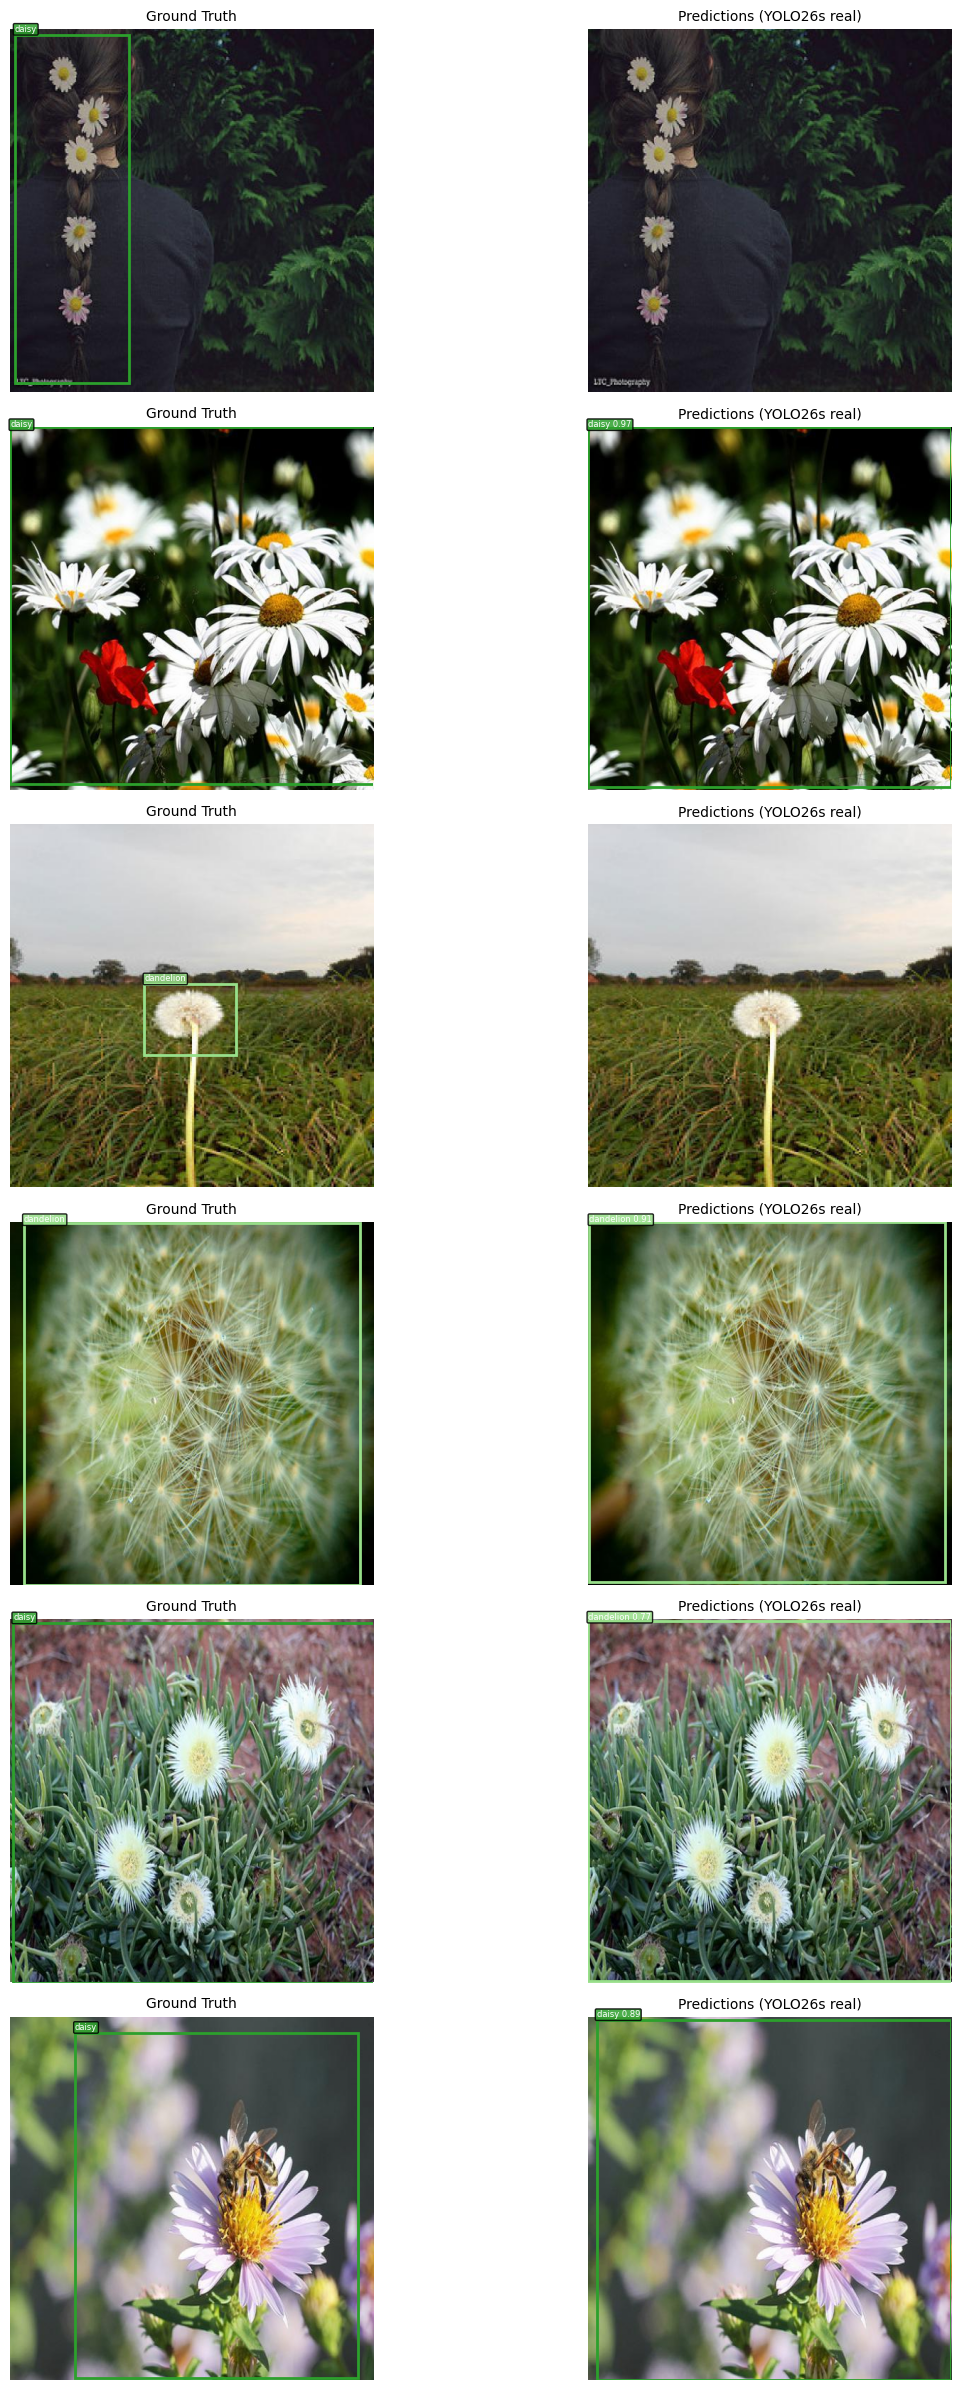

In [23]:
res_yolo_real = analyze_model(gt, preds_yolo_real, "YOLO26s — real-only")
visualize_predictions(gt, preds_yolo_real, "YOLO26s real")

### Case Study 1 — Discussion

**Observations** (fill in after running):
- Which classes have the highest / lowest AP?  Why might this be?
  (Hint: correlate with class frequency, object size, visual similarity)
- Is precision or recall the bottleneck?
  High precision + low recall → conservative detector (misses objects).
  Low precision + high recall → many false positives (hallucinates boxes).
- Look at the visualized predictions: does the model mis-localize, produce
  duplicates, or confuse visually similar classes?

**Proposed improvements:**
- If low recall on small flowers → increase input resolution or use YOLO26m.
- If class confusion → add more per-class training samples or use longer training.
- If many duplicates → lower NMS IoU threshold (though YOLO26 is NMS-free, the
  confidence threshold still matters).

## Case Study 2 — RF-DETR (real-only)

Analyze the transformer-based detector and compare its behaviour with YOLO26.  
RF-DETR uses a DINOv2 ViT backbone with deformable attention, so expect
different strengths (global context, better generalization) and weaknesses
(higher latency, more parameters).

  RF-DETR Base — real-only
  mAP@0.5 = 0.5884    mAP@0.75 = 0.4734

  Class                  AP@0.5     Prec      Rec       F1     GT     TP     FP
  ----------------------------------------------------------------------------
  butterfly flower        0.454    0.312    0.665    0.425    173    115    253
  cape flower             0.766    0.542    0.874    0.669    103     90     76
  cyclamen                0.781    0.429    0.886    0.579     79     70     93
  dahlia                  0.385    0.950    0.388    0.551     98     38      2
  daisy                   0.851    0.680    0.881    0.768    261    230    108
  dandelion               0.796    0.615    0.831    0.707    248    206    129
  foxglove                0.693    0.473    0.772    0.586    123     95    106
  frangipani              0.616    0.762    0.626    0.688    123     77     24
  jasmine                 0.472    0.479    0.605    0.535    261    158    172
  orchid                  0.784    0.539    0.822    

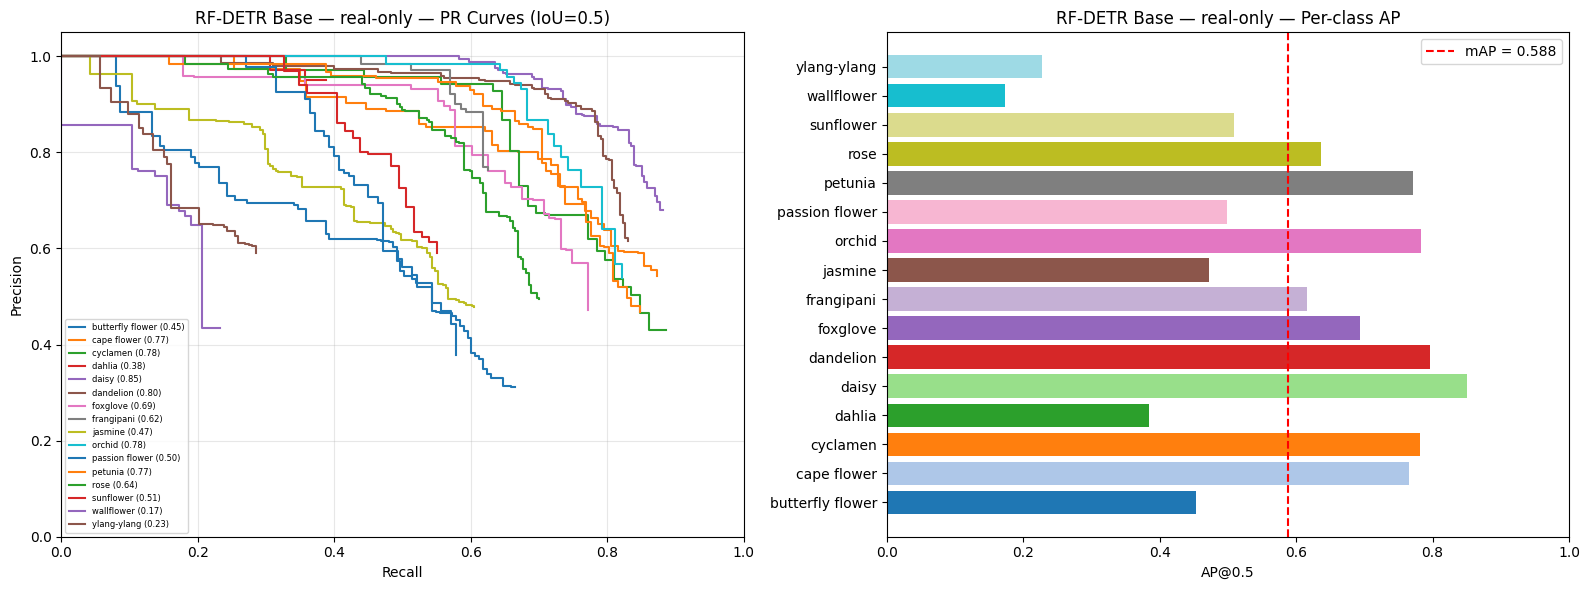

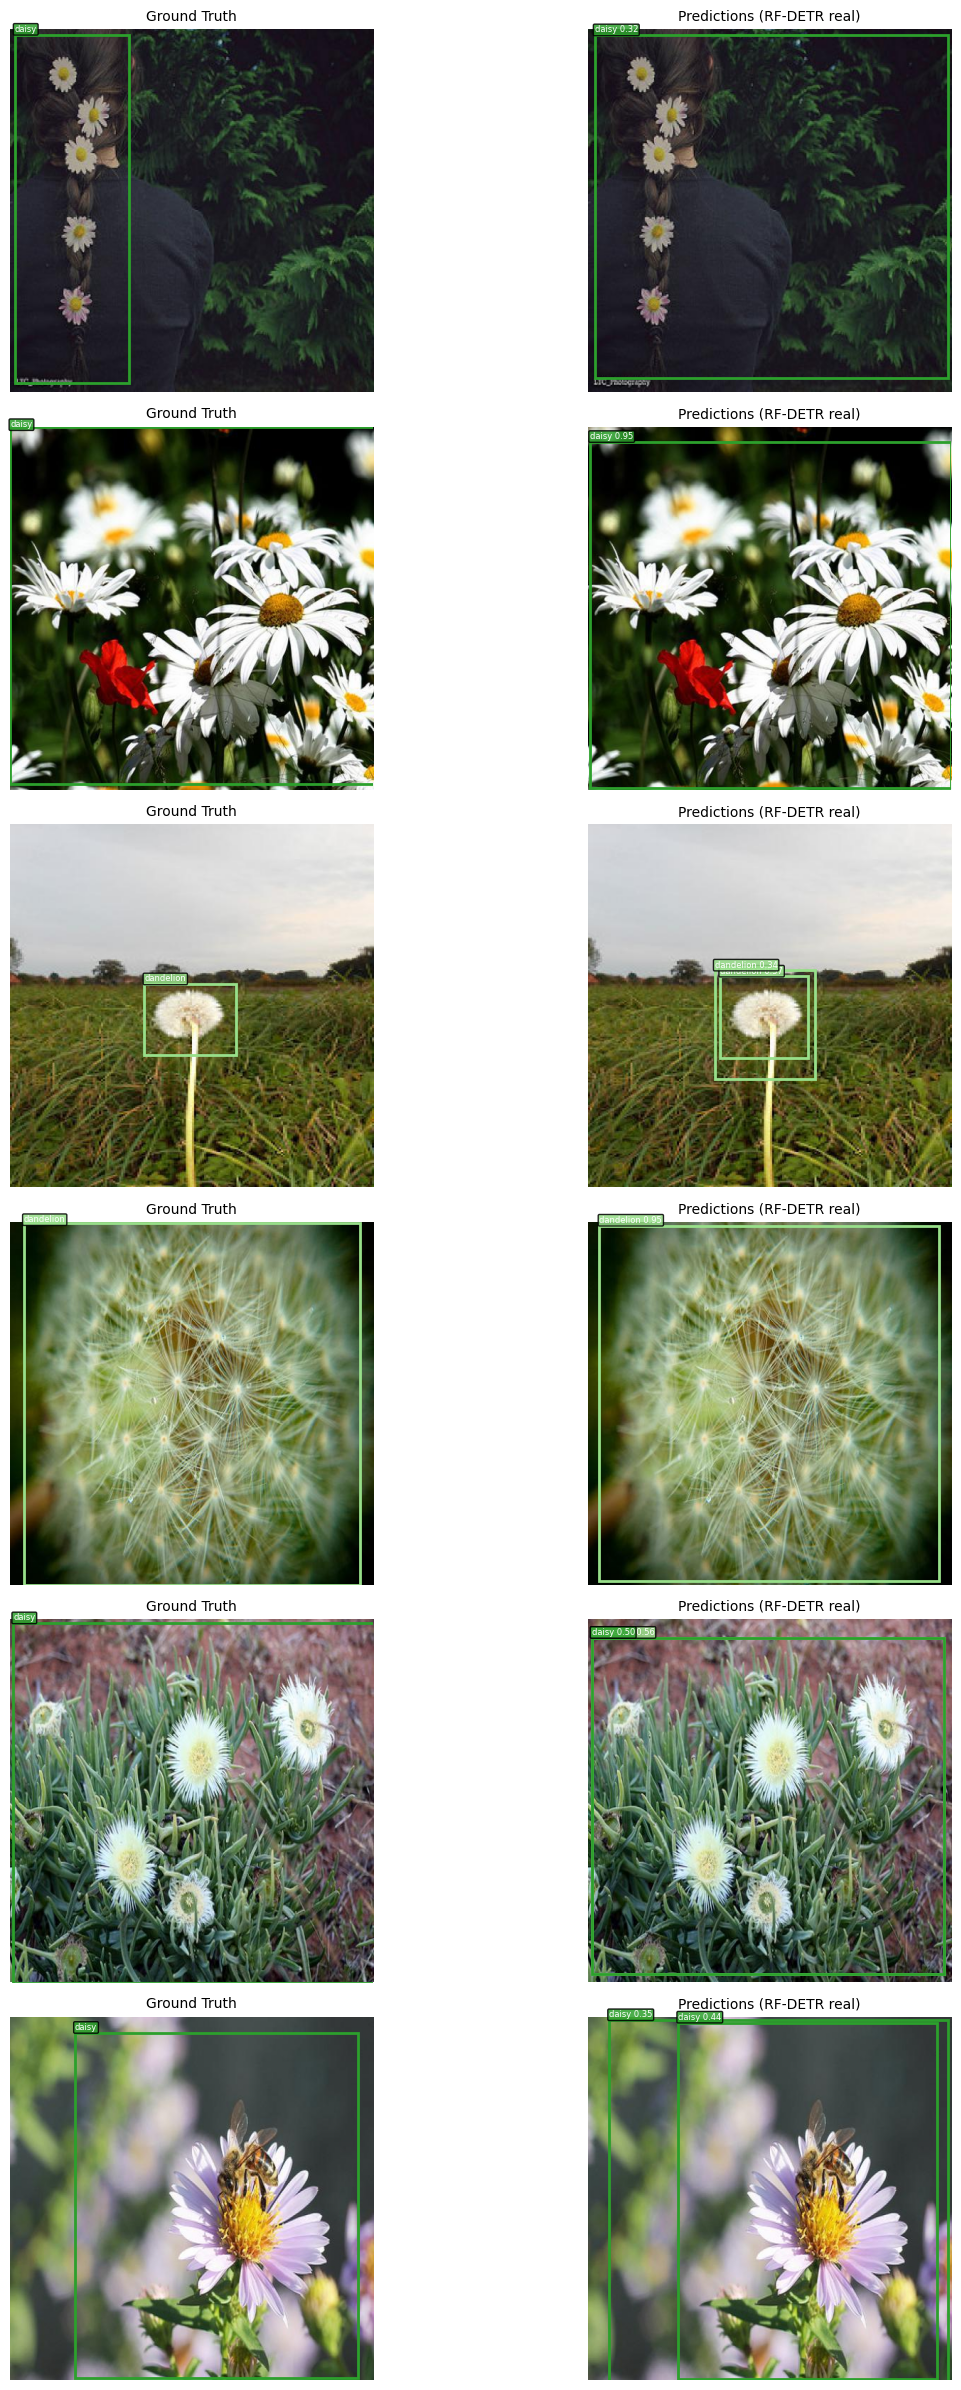

In [24]:
res_rfdetr_real = analyze_model(gt, preds_rfdetr_real, "RF-DETR Base — real-only")
visualize_predictions(gt, preds_rfdetr_real, "RF-DETR real")

### Case Study 2 — Discussion

**Observations** (fill in after running):
- How does RF-DETR's mAP compare to YOLO26 on this dataset?
- Does RF-DETR handle rare / under-represented classes better?
  (DINOv2 pre-training gives richer features even for few-shot classes)
- Compare precision-recall profiles: which model is more "aggressive" in
  predicting boxes?
- Look at failure cases: does RF-DETR localize better but confuse classes,
  or vice versa?

**Proposed improvements:**
- If under-performing → use RFDETRLarge (129M params) for higher capacity.
- If overfitting → reduce learning rate or add augmentation.
- For deployment: consider RF-DETR's higher latency vs YOLO26's speed.

## Case Study 3 — Comparative Analysis: YOLO26 vs RF-DETR, Real vs Real+Synthetic

Side-by-side comparison of all four models.  
Key questions:
1. Which architecture wins on this dataset and why?
2. Does adding synthetic (copy-paste) data improve detection performance?
3. Which classes benefit most from synthetic augmentation?

  YOLO26s — real+synth
  mAP@0.5 = 0.6090    mAP@0.75 = 0.4989

  Class                  AP@0.5     Prec      Rec       F1     GT     TP     FP
  ----------------------------------------------------------------------------
  butterfly flower        0.291    0.656    0.353    0.459    173     61     32
  cape flower             0.671    0.639    0.757    0.693    103     78     44
  cyclamen                0.615    0.891    0.620    0.731     79     49      6
  dahlia                  0.824    0.788    0.837    0.812     98     82     22
  daisy                   0.856    0.844    0.870    0.857    261    227     42
  dandelion               0.816    0.873    0.831    0.851    248    206     30
  foxglove                0.623    0.718    0.683    0.700    123     84     33
  frangipani              0.569    0.828    0.585    0.686    123     72     15
  jasmine                 0.348    0.600    0.494    0.542    261    129     86
  orchid                  0.701    0.783    0.713    0.74

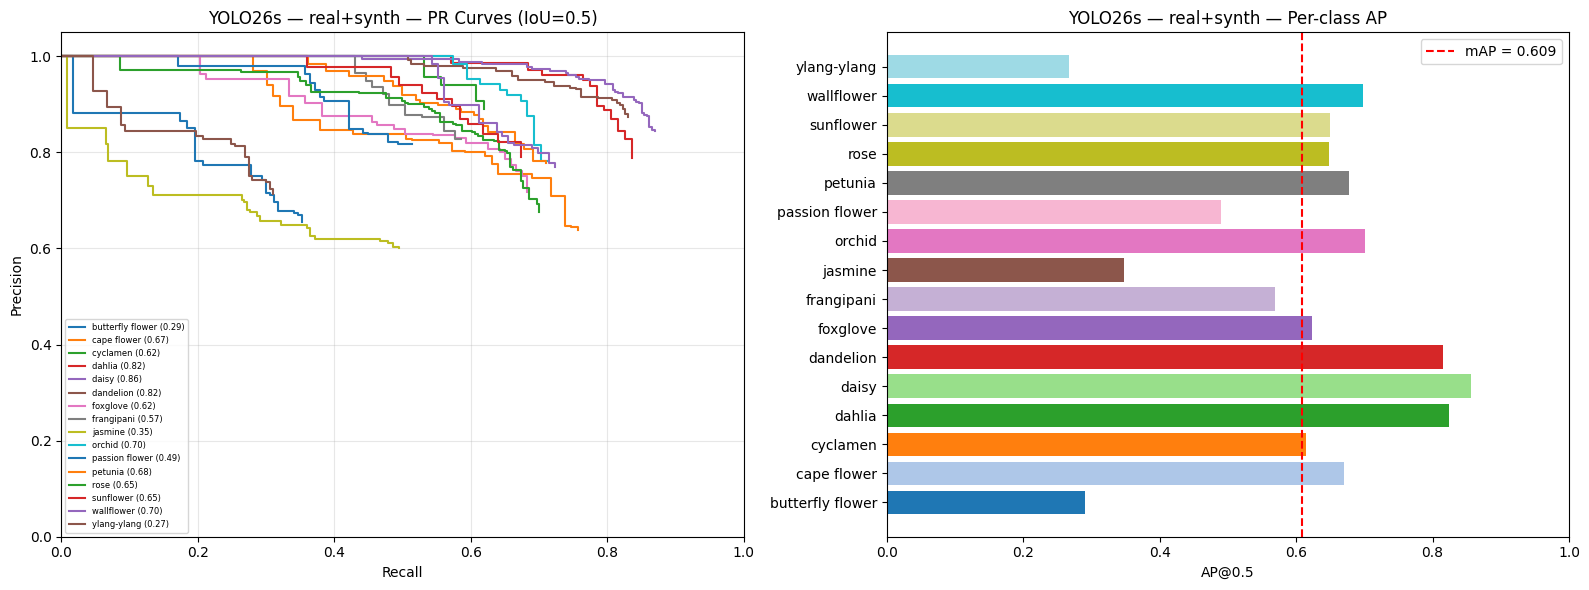


Model                        mAP@0.5   mAP@0.75    Δ synth @0.5
-----------------------------------------------------------------
YOLO26s real                  0.6217     0.5082                
YOLO26s real+synth            0.6090     0.4989         -0.0127
RF-DETR real                  0.5884     0.4734                


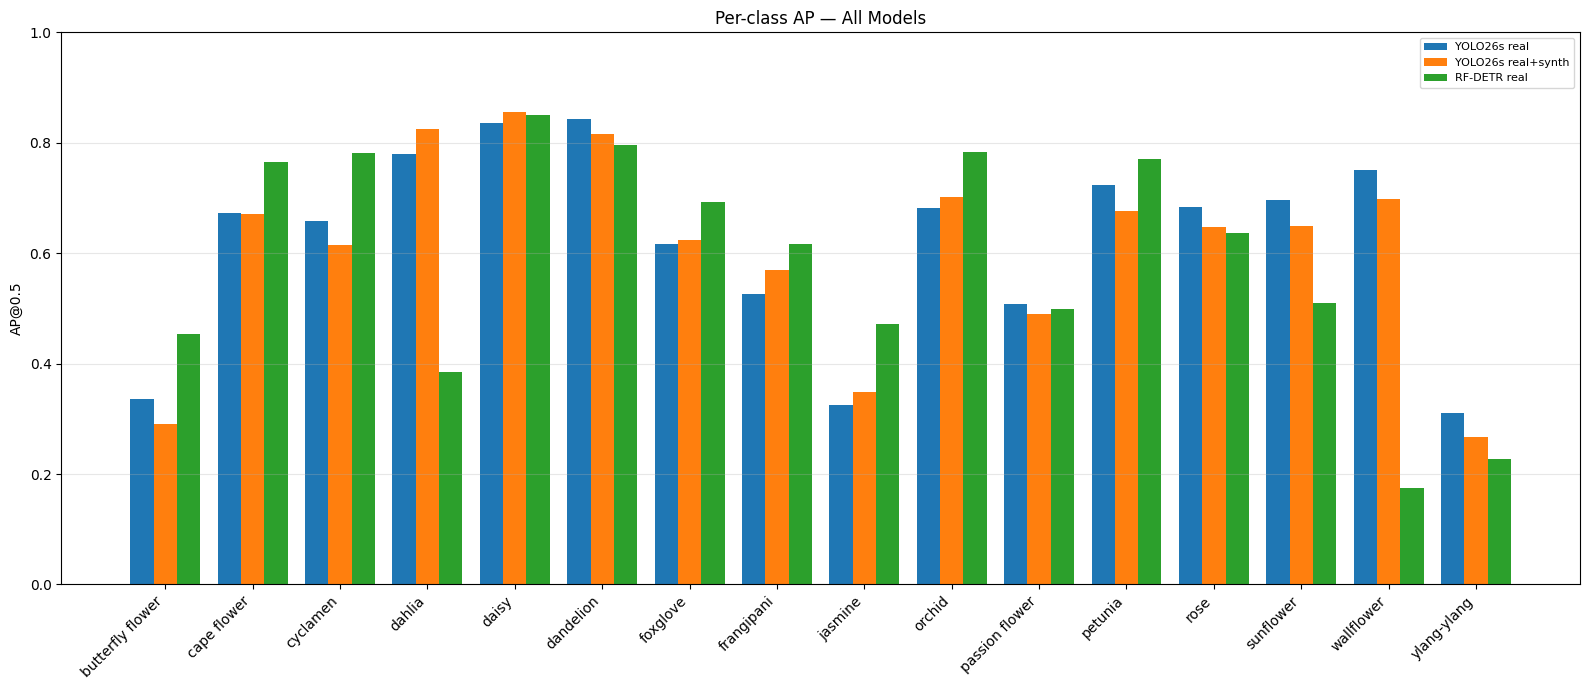

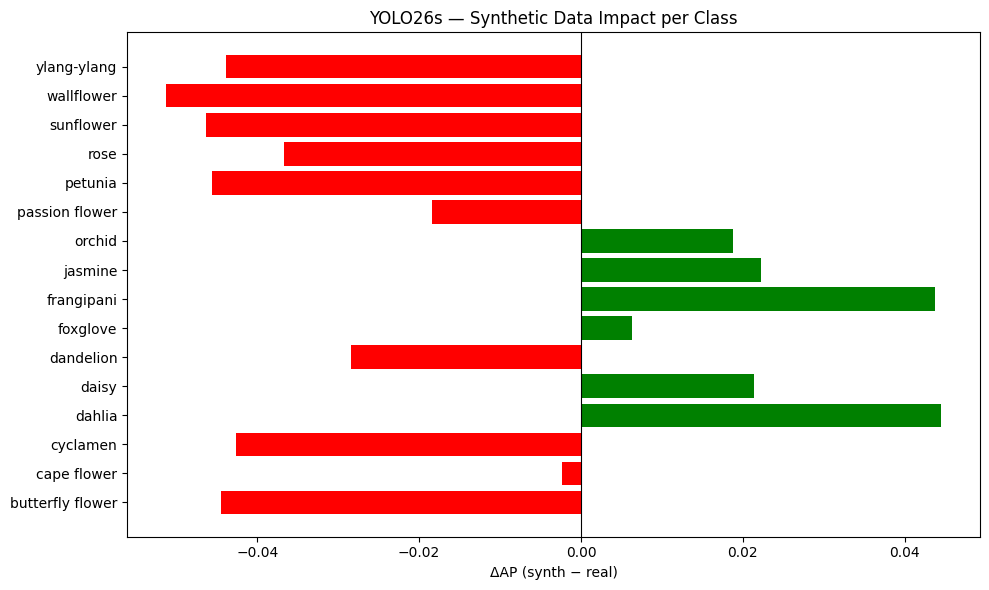

In [25]:
res_yolo_synth  = analyze_model(gt, preds_yolo_synth,  "YOLO26s — real+synth")

# ── Summary table ──
all_results = {
    "YOLO26s real":       res_yolo_real,
    "YOLO26s real+synth": res_yolo_synth,
    "RF-DETR real":       res_rfdetr_real,
}

print(f"\n{'Model':<25} {'mAP@0.5':>10} {'mAP@0.75':>10}  {'Δ synth @0.5':>14}")
print("-" * 65)
for name, (m50, m75, _) in all_results.items():
    delta = ""
    if "synth" in name:
        base = name.replace(" real+synth", " real")
        delta = f"{m50 - all_results[base][0]:+.4f}"
    print(f"{name:<25} {m50:>10.4f} {m75:>10.4f}  {delta:>14}")

# ── Grouped bar chart: per-class AP for all 3 models ──
fig, ax = plt.subplots(figsize=(16, 7))
n_cls = len(ALL_CLASSES)
n_mod = len(all_results)
bw = 0.8 / n_mod
x = np.arange(n_cls)

for i, (name, (_, _, pc)) in enumerate(all_results.items()):
    aps = [pc[c]["ap"] for c in ALL_CLASSES]
    ax.bar(x + i * bw, aps, bw, label=name)

ax.set_xticks(x + bw * (n_mod - 1) / 2)
ax.set_xticklabels([cat_map[c] for c in ALL_CLASSES], rotation=45, ha="right")
ax.set(ylabel="AP@0.5", title="Per-class AP — All Models", ylim=(0, 1))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── Synthetic data impact per class (YOLO26 only) ──
fig, ax = plt.subplots(figsize=(10, 6))
base_pc = all_results["YOLO26s real"][2]
synth_pc = all_results["YOLO26s real+synth"][2]
deltas = [synth_pc[c]["ap"] - base_pc[c]["ap"] for c in ALL_CLASSES]
colors = ["green" if d >= 0 else "red" for d in deltas]
ax.barh([cat_map[c] for c in ALL_CLASSES], deltas, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set(xlabel="ΔAP (synth − real)", title="YOLO26s — Synthetic Data Impact per Class")
plt.tight_layout()
plt.show()

### Case Study 3 — Discussion

**Architecture comparison:**
- YOLO26 is a CNN with NMS-free heads → fast inference, lower parameters.
  From the paper: YOLO26s has 9.5M params, 2.5ms on T4.
- RF-DETR uses a ViT backbone + decoder → richer features, better domain transfer.
  From the paper: RF-DETR (N) has 30.5M params, 2.3ms on T4.
- On COCO, RF-DETR generally edges out YOLO26 in accuracy at similar latency.
  On a small custom dataset, the gap may be larger (DINOv2 pre-training helps) or smaller
  (YOLO26 benefits from heavy augmentation built into ultralytics).

**Synthetic data impact:**
- If ΔAP is positive → copy-paste augmentation helped that class.
  This is expected for **under-represented** classes where synthetic samples
  effectively balance the training distribution.
- If ΔAP is negative → synthetic samples may introduce distribution shift
  (unrealistic backgrounds, wrong scale) or dilute the real signal.
- Compare the magnitude of improvement per model: transformer models
  (RF-DETR) may benefit less since DINOv2 already provides strong priors.

**Real-world deployment considerations:**
- YOLO26: best for edge / mobile / real-time applications. Simpler export pipeline.
- RF-DETR: best when accuracy matters most and GPU inference is available.
- Synthetic data: cheap to generate, worth trying, but gains are dataset-dependent.

## Log Evaluation Results to wandb

In [27]:
run = wandb.init(project="lab6-flower-detection", name="evaluation_summary", job_type="eval")

rows = []
for name, (m50, m75, pc) in all_results.items():
    for c in ALL_CLASSES:
        r = pc[c]
        rows.append([name, cat_map[c], r["ap"], r["precision"], r["recall"],
                      r["f1"], r["num_gt"], r["tp"], r["fp"]])

table = wandb.Table(
    columns=["model", "class", "AP@0.5", "precision", "recall",
             "F1", "num_gt", "TP", "FP"],
    data=rows,
)
run.log({"evaluation_table": table})

for name, (m50, m75, _) in all_results.items():
    safe = name.replace(" ", "_").replace("+", "_")
    run.summary[f"{safe}/mAP50"] = m50
    run.summary[f"{safe}/mAP75"] = m75

# Log sample prediction images
for model_name, preds in [
    ("YOLO26s_real", preds_yolo_real),
    ("RF-DETR_real", preds_rfdetr_real),
]:
    wb_images = []
    sample_ids = [k for k in gt if len(gt[k]) > 0][:8]
    for img_id in sample_ids:
        img_files = list(TEST_IMG_DIR.glob(f"{img_id}.*"))
        if not img_files:
            continue
        img = cv2.imread(str(img_files[0]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        box_data = []
        for b in gt[img_id]:
            cx, cy, bw, bh = b["bbox"]
            box_data.append({
                "position": {"middle": [cx * w, cy * h], "width": bw * w, "height": bh * h},
                "class_id": b["class_id"],
                "box_caption": cat_map.get(b["class_id"], "?"),
                "domain": "pixel",
            })
        for b in preds.get(img_id, []):
            if b["confidence"] < 0.3:
                continue
            cx, cy, bw, bh = b["bbox"]
            box_data.append({
                "position": {"middle": [cx * w, cy * h], "width": bw * w, "height": bh * h},
                "class_id": b["class_id"] + num_classes,
                "box_caption": f"pred: {cat_map.get(b['class_id'], '?')} {b['confidence']:.2f}",
                "domain": "pixel",
                "scores": {"confidence": b["confidence"]},
            })

        class_labels = {i: cat_map[i] for i in ALL_CLASSES}
        class_labels.update({i + num_classes: f"pred_{cat_map[i]}" for i in ALL_CLASSES})

        wb_images.append(wandb.Image(
            img,
            boxes={"predictions": {"box_data": box_data, "class_labels": class_labels}},
        ))
    run.log({f"{model_name}_predictions": wb_images})

wandb.finish()
print("Results logged to wandb.")

RF-DETR_real/mAP50,0.58843
RF-DETR_real/mAP75,0.47337
YOLO26s_real/mAP50,0.62175
YOLO26s_real/mAP75,0.50819
YOLO26s_real_synth/mAP50,0.60905
YOLO26s_real_synth/mAP75,0.4989


Results logged to wandb.
